In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import timm
import os
import sys
import gc
import matplotlib.pyplot as plt

# Set absolute paths
PROJECT_ROOT = r'd:\Projects\ML_Algorithms\batchsize'
IMAGE_PATH = r'E:\covidx'
TRAIN_CSV = os.path.join(IMAGE_PATH, 'covidx_merged.csv')

# Add project root and functions to path
if PROJECT_ROOT not in sys.path: sys.path.append(PROJECT_ROOT)
functions_path = os.path.join(PROJECT_ROOT, "functions")
if functions_path not in sys.path: sys.path.append(functions_path)

from dataset import COVIDCXNetDataset
from train import train
from evaluation import plot_results

# Fixed Seed for Reproducibility
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


c:\Users\Furkan\Miniconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
batch_sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


Using device: cuda


In [ ]:
results = {}

# Aggressive cleanup before starting experiments
gc.collect()
torch.cuda.empty_cache()

for bs in batch_sizes:
    print(f"\n{'='*30}\nRunning experiment with Batch Size: {bs}\n{'='*30}")
    
    try:
        # Dataset & Dataloader
        ROOT_DATA_DIR = os.path.dirname(IMAGE_PATH) # E:\\
        train_ds = COVIDCXNetDataset(TRAIN_CSV, ROOT_DATA_DIR, transform=transform, split='train')
        val_ds = COVIDCXNetDataset(TRAIN_CSV, ROOT_DATA_DIR, transform=transform, split='val')
        
        train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4, pin_memory=True)
        val_loader = DataLoader(val_ds, batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)
        
        model = timm.create_model('resnet50', pretrained=True)
        model.reset_classifier(num_classes=2)
        model.to(device)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        # Prepare paths
        save_dir = os.path.join(PROJECT_ROOT, 'models')
        log_dir = os.path.join(PROJECT_ROOT, 'logs')
        os.makedirs(save_dir, exist_ok=True)
        os.makedirs(log_dir, exist_ok=True)

        save_path = os.path.join(save_dir, f'resnet50_bs{bs}.pth')
        log_path = os.path.join(log_dir, f'resnet50_bs{bs}.log')

        # Train
        train_losses, train_accs, val_losses, val_accs = train(
            model, train_loader, val_loader, criterion, optimizer, device,
            save_path=save_path, num_epochs=num_epochs, patience=3, log_path=log_path
        )

        # Store results
        results[bs] = max(val_accs)
        print(f"Best Val Acc for BS {bs}: {results[bs]:.4f}")
        
    except torch.cuda.OutOfMemoryError:
        print(f"CRITICAL: Out of Memory for Batch Size {bs}. Skipping higher batch sizes.")
        break
    except Exception as e:
        print(f"An error occurred with Batch Size {bs}: {e}")
    finally:
        # Cleanup memory
        mem_before = torch.cuda.memory_reserved() if torch.cuda.is_available() else 0
        
        if 'model' in locals(): del model
        if 'optimizer' in locals(): del optimizer
        if 'train_loader' in locals(): del train_loader
        if 'val_loader' in locals(): del val_loader
        if 'train_ds' in locals(): del train_ds
        if 'val_ds' in locals(): del val_ds
        
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            mem_after = torch.cuda.memory_reserved()
            cleared_mb = (mem_before - mem_after) / (1024 ** 2)
            print(f"Memory cleared after BS {bs}: {cleared_mb:.2f} MB.")
        else:
            print(f"Memory cleared after BS {bs}.")



Running experiment with Batch Size: 8
Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Original samples: 8473
Valid AP/PA samples: 4186
Loaded 4186 samples for split 'val'
Class distribution: PA=1275, AP=2911


[2026_02_16_08_59_24] Training started.
Epoch 1/5 - Validation: 100%|██████████| 524/524 [00:19<00:00, 27.04it/s]
[2026_02_16_09_03_51] Epoch [1/5]
[2026_02_16_09_03_51]   Train Loss: 0.1227, Train Acc: 0.9593
[2026_02_16_09_03_51]   Val   Loss: 0.1580, Val   Acc: 0.9546
[2026_02_16_09_03_51]   Best model saved with val_loss: 0.1580


Epoch [1/5]
  Train Loss: 0.1227, Train Acc: 0.9593
  Val   Loss: 0.1580, Val   Acc: 0.9546
  Best model saved with val_loss: 0.1580


Epoch 2/5 - Validation: 100%|██████████| 524/524 [00:17<00:00, 29.33it/s]
[2026_02_16_09_08_17] Epoch [2/5]
[2026_02_16_09_08_17]   Train Loss: 0.0782, Train Acc: 0.9755
[2026_02_16_09_08_17]   Val   Loss: 0.1504, Val   Acc: 0.9484
[2026_02_16_09_08_17]   Best model saved with val_loss: 0.1504


Epoch [2/5]
  Train Loss: 0.0782, Train Acc: 0.9755
  Val   Loss: 0.1504, Val   Acc: 0.9484
  Best model saved with val_loss: 0.1504


...

Epoch [4/5]
  Train Loss: 0.0262, Train Acc: 0.9910
  Val   Loss: 0.0995, Val   Acc: 0.9670
  Best model saved with val_loss: 0.0995


Epoch 5/5 - Validation: 100%|██████████| 33/33 [00:47<00:00,  1.43s/it]
[2026_02_16_13_21_34] Epoch [5/5]
[2026_02_16_13_21_34]   Train Loss: 0.0206, Train Acc: 0.9927
[2026_02_16_13_21_34]   Val   Loss: 0.1224, Val   Acc: 0.9558
[2026_02_16_13_21_34]   No improvement. Early stopping counter: 1/3
[2026_02_16_13_21_34] 
========== BEST MODEL SUMMARY ==========
[2026_02_16_13_21_34] Best Epoch      : 4
[2026_02_16_13_21_34] Val Loss        : 0.0995
[2026_02_16_13_21_34] ========================================


Epoch [5/5]
  Train Loss: 0.0206, Train Acc: 0.9927
  Val   Loss: 0.1224, Val   Acc: 0.9558
  No improvement. Early stopping counter: 1/3

========== BEST MODEL SUMMARY ==========
Best Epoch      : 4
Val Loss        : 0.0995
Best Val Acc for BS 128: 0.9670
Memory cleared after BS 128: 12124.00 MB.

Running experiment with Batch Size: 256
Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Original samples: 8473
Valid AP/PA samples: 4186
Loaded 4186 samples for split 'val'
Class distribution: PA=1275, AP=2911


[2026_02_16_13_21_35] Training started.
Epoch 1/5 - Training:   0%|          | 0/210 [00:19<?, ?it/s]


CRITICAL: Out of Memory for Batch Size 256. Skipping higher batch sizes.
Memory cleared after BS 256: 19006.00 MB.


In [4]:
 # Cleanup memory
mem_before = torch.cuda.memory_reserved() if torch.cuda.is_available() else 0

if 'model' in locals(): del model
if 'optimizer' in locals(): del optimizer
if 'train_loader' in locals(): del train_loader
if 'val_loader' in locals(): del val_loader
if 'train_ds' in locals(): del train_ds
if 'val_ds' in locals(): del val_ds

gc.collect()

torch.cuda.empty_cache()
mem_after = torch.cuda.memory_reserved()
cleared_mb = (mem_before - mem_after) / (1024 ** 2)
print(f"Memory cleared: {cleared_mb:.2f} MB")

results = {}

bs = 211

print(f"\n{'='*30}\nRunning experiment with Batch Size: {bs}\n{'='*30}")


# Dataset & Dataloader
ROOT_DATA_DIR = os.path.dirname(IMAGE_PATH) # E:\\
train_ds = COVIDCXNetDataset(TRAIN_CSV, ROOT_DATA_DIR, transform=transform, split='train')
val_ds = COVIDCXNetDataset(TRAIN_CSV, ROOT_DATA_DIR, transform=transform, split='val')

train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)

model = timm.create_model('resnet50', pretrained=True)
model.reset_classifier(num_classes=2)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Prepare paths
save_dir = os.path.join(PROJECT_ROOT, 'models')
log_dir = os.path.join(PROJECT_ROOT, 'logs')
os.makedirs(save_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

save_path = os.path.join(save_dir, f'resnet50_bs{bs}.pth')
log_path = os.path.join(log_dir, f'resnet50_bs{bs}.log')

# Train
train_losses, train_accs, val_losses, val_accs = train(
    model, train_loader, val_loader, criterion, optimizer, device,
    save_path=save_path, num_epochs=num_epochs, patience=3, log_path=log_path
)

# Store results
results[bs] = max(val_accs)
print(f"Best Val Acc for BS {bs}: {results[bs]:.4f}")


Memory cleared: 1550.00 MB

Running experiment with Batch Size: 211
Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Original samples: 8473
Valid AP/PA samples: 4186
Loaded 4186 samples for split 'val'
Class distribution: PA=1275, AP=2911


[2026_02_17_01_28_29] Training started.
Epoch 1/5 - Validation: 100%|██████████| 20/20 [01:19<00:00,  3.96s/it]
[2026_02_17_02_10_19] Epoch [1/5]
[2026_02_17_02_10_19]   Train Loss: 0.1096, Train Acc: 0.9602
[2026_02_17_02_10_19]   Val   Loss: 0.1318, Val   Acc: 0.9544
[2026_02_17_02_10_19]   Best model saved with val_loss: 0.1318


Epoch [1/5]
  Train Loss: 0.1096, Train Acc: 0.9602
  Val   Loss: 0.1318, Val   Acc: 0.9544
  Best model saved with val_loss: 0.1318


Epoch 2/5 - Validation: 100%|██████████| 20/20 [01:18<00:00,  3.94s/it]
[2026_02_17_02_52_52] Epoch [2/5]
[2026_02_17_02_52_52]   Train Loss: 0.0497, Train Acc: 0.9843
[2026_02_17_02_52_52]   Val   Loss: 0.1146, Val   Acc: 0.9630
[2026_02_17_02_52_52]   Best model saved with val_loss: 0.1146


Epoch [2/5]
  Train Loss: 0.0497, Train Acc: 0.9843
  Val   Loss: 0.1146, Val   Acc: 0.9630
  Best model saved with val_loss: 0.1146


...

Epoch [3/5]
  Train Loss: 0.0321, Train Acc: 0.9893
  Val   Loss: 0.2309, Val   Acc: 0.8911
  No improvement. Early stopping counter: 1/3


Epoch 4/5 - Validation: 100%|██████████| 20/20 [01:19<00:00,  3.96s/it]
[2026_02_17_04_18_24] Epoch [4/5]
[2026_02_17_04_18_24]   Train Loss: 0.0251, Train Acc: 0.9914
[2026_02_17_04_18_24]   Val   Loss: 0.1505, Val   Acc: 0.9494
[2026_02_17_04_18_24]   No improvement. Early stopping counter: 2/3


Epoch [4/5]
  Train Loss: 0.0251, Train Acc: 0.9914
  Val   Loss: 0.1505, Val   Acc: 0.9494
  No improvement. Early stopping counter: 2/3


Epoch 5/5 - Validation: 100%|██████████| 20/20 [01:19<00:00,  3.97s/it]
[2026_02_17_05_01_13] Epoch [5/5]
[2026_02_17_05_01_13]   Train Loss: 0.0176, Train Acc: 0.9939
[2026_02_17_05_01_13]   Val   Loss: 0.3265, Val   Acc: 0.9360
[2026_02_17_05_01_13]   No improvement. Early stopping counter: 3/3
[2026_02_17_05_01_13]   Early stopping triggered. Training stopped.
[2026_02_17_05_01_13] 
========== BEST MODEL SUMMARY ==========
[2026_02_17_05_01_13] Best Epoch      : 2
[2026_02_17_05_01_13] Val Loss        : 0.1146
[2026_02_17_05_01_13] ========================================


Epoch [5/5]
  Train Loss: 0.0176, Train Acc: 0.9939
  Val   Loss: 0.3265, Val   Acc: 0.9360
  No improvement. Early stopping counter: 3/3
  Early stopping triggered. Training stopped.

========== BEST MODEL SUMMARY ==========
Best Epoch      : 2
Val Loss        : 0.1146
Best Val Acc for BS 211: 0.9630


In [3]:
import torch
import gc

def find_max_batch_size(device, transform, min_bs=8, max_bs=4096):
    print(f"\nSearching for maximum Batch Size in range [{min_bs}, {max_bs}]...")
    
    best_bs = min_bs
    low = min_bs
    high = max_bs
    
    while low <= high:
        bs = (low + high) // 2
        if bs == 0: break
        
        print(f"\nTesting Batch Size: {bs}...")
        
        try:
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()   # 🔥 PEAK reset
            
            dummy_model = timm.create_model('resnet50', pretrained=False).to(device)
            dummy_optimizer = optim.Adam(dummy_model.parameters())
            dummy_criterion = nn.CrossEntropyLoss()
            
            x = torch.randn(bs, 3, 224, 224).to(device)
            y = torch.randint(0, 2, (bs,)).to(device)
            
            dummy_optimizer.zero_grad()
            output = dummy_model(x)
            loss = dummy_criterion(output, y)
            loss.backward()
            dummy_optimizer.step()
            
            # 🔥 VRAM ölçümü
            allocated = torch.cuda.memory_allocated() / 1024**2
            reserved = torch.cuda.memory_reserved() / 1024**2
            peak = torch.cuda.max_memory_allocated() / 1024**2
            
            print(f"SUCCESS | Allocated: {allocated:.2f} MB | "
                  f"Reserved: {reserved:.2f} MB | "
                  f"Peak: {peak:.2f} MB")
            
            best_bs = bs
            low = bs + 1
            
        except torch.cuda.OutOfMemoryError:
            print("OOM ❌")
            high = bs - 1
            
        except Exception as e:
            print(f"ERROR: {e}")
            high = bs - 1
            
        finally:
            if 'dummy_model' in locals(): del dummy_model
            if 'x' in locals(): del x
            if 'y' in locals(): del y
            if 'output' in locals(): del output
            if 'loss' in locals(): del loss
            gc.collect()
            torch.cuda.empty_cache()
                
    print(f"\n>>> Maximum working Batch Size found: {best_bs} <<<")
    
    safe_bs = int(best_bs * 0.8)
    print(f">>> Recommended Safe Batch Size: {safe_bs} <<<")
    
    return safe_bs


# Run detection
max_working_bs = find_max_batch_size(device, transform)



Searching for maximum Batch Size in range [8, 4096]...

Testing Batch Size: 2052...
OOM ❌

Testing Batch Size: 1029...
OOM ❌

Testing Batch Size: 518...
OOM ❌

Testing Batch Size: 262...
SUCCESS | Allocated: 665.02 MB | Reserved: 17104.00 MB | Peak: 21900.12 MB

Testing Batch Size: 390...
OOM ❌

Testing Batch Size: 326...
OOM ❌

Testing Batch Size: 294...
OOM ❌

Testing Batch Size: 278...
OOM ❌

Testing Batch Size: 270...
OOM ❌

Testing Batch Size: 266...
OOM ❌

Testing Batch Size: 264...
SUCCESS | Allocated: 665.27 MB | Reserved: 20552.00 MB | Peak: 22067.91 MB

Testing Batch Size: 265...
OOM ❌

>>> Maximum working Batch Size found: 264 <<<
>>> Recommended Safe Batch Size: 211 <<<


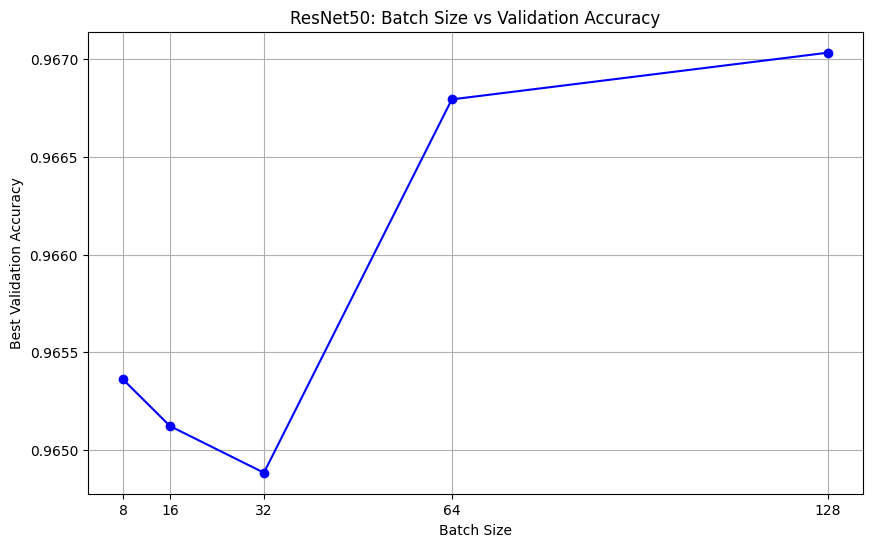

In [4]:
# Visualization
if results:
    plt.figure(figsize=(10, 6))
    plt.plot(list(results.keys()), list(results.values()), marker='o', linestyle='-', color='b')
    plt.title('ResNet50: Batch Size vs Validation Accuracy')
    plt.xlabel('Batch Size')
    plt.ylabel('Best Validation Accuracy')
    plt.grid(True)
    plt.xticks(list(results.keys()))
    plt.show()
else:
    print("No successful experiments to visualize.")


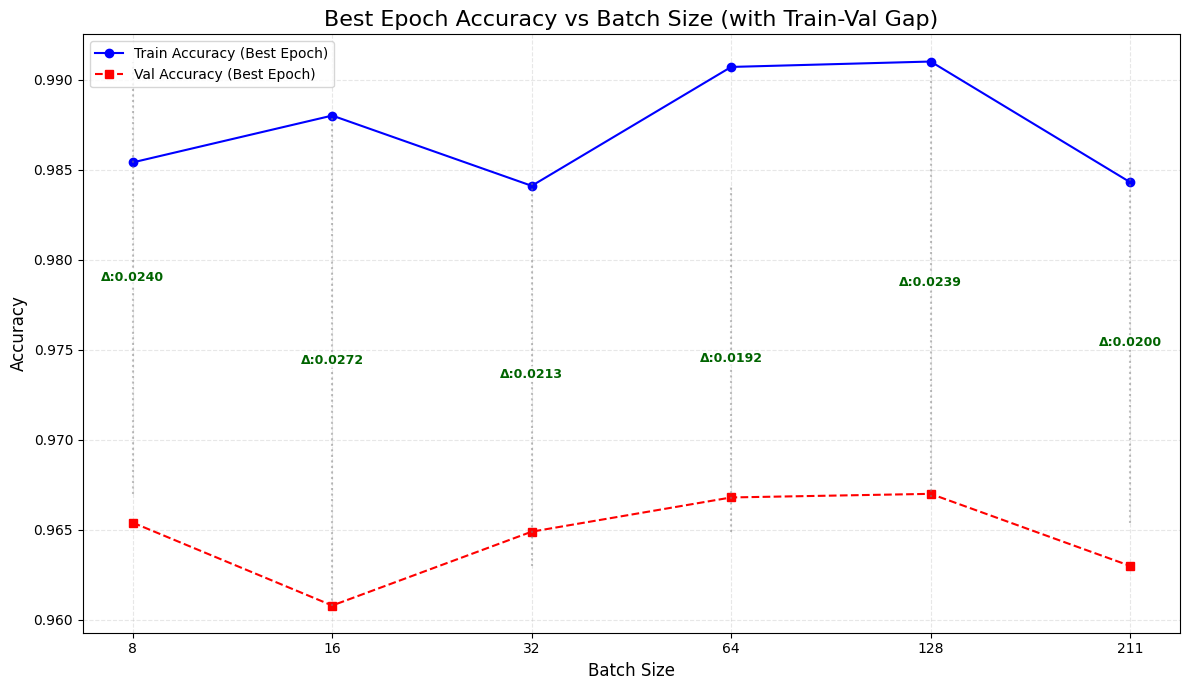


--- Detailed Results (Δ = Train - Val) ---


Batch Size,Epoch,Train Acc,Val Acc,Diff,Is Best
8,1,0.9593,0.9546,0.0047,False
8,2,0.9755,0.9484,0.0271,False
8,3,0.9791,0.9632,0.0159,False
8,4,0.9835,0.9615,0.0220,False
8,5,0.9854,0.9654,0.0200,True
16,1,0.9631,0.9539,0.0092,False
16,2,0.9776,0.9651,0.0125,False
16,3,0.9824,0.9620,0.0204,False
16,4,0.9846,0.9644,0.0202,False
16,5,0.9880,0.9608,0.0272,True


In [8]:
import os
import re
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Visualization of Best Accuracy from Logs (Fixed Logic)
log_dir = os.path.join(PROJECT_ROOT, 'logs')
log_files = [f for f in os.listdir(log_dir) if f.startswith('resnet50_bs') and f.endswith('.log')]

best_results = []
all_results = []

for filename in log_files:
    bs_match = re.search(r'bs(\d+)', filename)
    if not bs_match: continue
    bs = int(bs_match.group(1))
    
    with open(os.path.join(log_dir, filename), 'r') as f:
        content = f.read()
    
    # Split by "Training started." and take the last run
    runs = content.split("Training started.")
    if len(runs) < 2: continue
    last_run = runs[-1]
    
    # Extract Accuracy for all epochs
    epochs_raw = re.findall(r'Epoch \[(\d+)/\d+\]', last_run)
    train_accs_raw = re.findall(r'Train Acc: ([\d.]+)', last_run)
    val_accs_raw = re.findall(r'Val\s+Acc: ([\d.]+)', last_run)
    
    if epochs_raw and train_accs_raw and val_accs_raw:
        min_len = min(len(epochs_raw), len(train_accs_raw), len(val_accs_raw))
        
        run_data = []
        best_val_acc = -1.0
        best_epoch_idx = -1
        
        for i in range(min_len):
            ep = int(epochs_raw[i])
            t_acc = float(train_accs_raw[i])
            v_acc = float(val_accs_raw[i])
            diff = round(t_acc - v_acc, 4)  # Round to avoid precision issues
            
            # Identify Best Epoch based on Validation Accuracy
            if v_acc > best_val_acc:
                best_val_acc = v_acc
                best_epoch_idx = ep
            
            run_data.append({
                'Batch Size': bs,
                'Epoch': ep,
                'Train Acc': t_acc,
                'Val Acc': v_acc,
                'Diff': diff
            })
        
        # Add to all_results and mark the best one
        for item in run_data:
            is_best = (item['Epoch'] == best_epoch_idx)
            item['Is Best'] = is_best
            all_results.append(item)
            
            if is_best:
                best_results.append({
                    'Batch Size': bs,
                    'Best Epoch': item['Epoch'],
                    'Train Acc (Best)': item['Train Acc'],
                    'Val Acc (Best)': item['Val Acc'],
                    'Diff (Best)': item['Diff']
                })

# 1. Visualization (Best Accuracy vs Batch Size + Difference)
if best_results:
    df_best = pd.DataFrame(best_results).sort_values('Batch Size')
    
    plt.figure(figsize=(12, 7))
    x_positions = range(len(df_best))
    bs_labels = df_best['Batch Size'].astype(str).tolist()
    
    plt.plot(x_positions, df_best['Train Acc (Best)'], 
             marker='o', linestyle='-', color='blue', label='Train Accuracy (Best Accuracy Epoch)')
    plt.plot(x_positions, df_best['Val Acc (Best)'], 
             marker='s', linestyle='--', color='red', label='Val Accuracy (Best Accuracy Epoch)')
    
    # Annotate differences
    for i, row in df_best.iterrows():
        x = i
        y_train = row['Train Acc (Best)']
        y_val = row['Val Acc (Best)']
        diff = row['Diff (Best)']
        
        # Draw a line between train and val
        plt.vlines(x, y_val, y_train, color='gray', linestyle=':', alpha=0.5)
        
        # Annotate text (Delta)
        text_y = (y_train + y_val) / 2
        plt.text(x, text_y, f'Δ:{diff:.4f}', 
                 horizontalalignment='center', verticalalignment='center',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1),
                 fontsize=9, fontweight='bold', color='darkgreen')

    plt.title('Best Accuracy vs Batch Size (Gaps Calculated Corrected)', fontsize=16)
    plt.xlabel('Batch Size', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xticks(x_positions, bs_labels)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 2. Detailed Table
    df_all = pd.DataFrame(all_results).sort_values(['Batch Size', 'Epoch'])
    print("\n--- Detailed Results (Corrected Diff & Accuracy-Based Best Highlights) ---")
    
    display(df_all.style.format({'Train Acc': '{:.4f}', 'Val Acc': '{:.4f}', 'Diff': '{:.4f}'})
            .map(lambda x: 'font-weight: bold; color: green' if x else '', subset=['Is Best'])
            .hide(axis='index'))
else:
    print("No valid training summaries found in logs.")

In [4]:
# New Cell for Batch Size Experiment (Sample Data)
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import models, transforms
import numpy as np
import gc
from tqdm import tqdm


# --- Dataset Setup ---
print("Setting up dataset...")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load Full Dataset (for splitting intro sample)
full_dataset = COVIDCXNetDataset(csv_file=TRAIN_CSV, root_dir=os.path.dirname(IMAGE_PATH), transform=transform, split='train')

# Create Sample Subsets (2000 Train, 500 Val)
# Using fixed indices for reproducibility
indices = list(range(len(full_dataset)))
# Shuffle indices securely
np.random.seed(42)
np.random.shuffle(indices)

sample_train_indices = indices[:2000]
sample_val_indices = indices[2000:2500]

train_subset = Subset(full_dataset, sample_train_indices)
val_subset = Subset(full_dataset, sample_val_indices)

print(f"Sample Train Size: {len(train_subset)}")
print(f"Sample Val Size: {len(val_subset)}")

# --- Batch Size Experiment ---
batch_sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

results = {}

for bs in batch_sizes:
    print(f"\n--- Testing Batch Size: {bs} ---")
    try:
        # 1. Clear Memory
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        # 2. DataLoaders
        train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True, num_workers=4)
        val_loader = DataLoader(val_subset, batch_size=bs, shuffle=False, num_workers=4)

        model = timm.create_model('resnet50', pretrained=True)
        model.reset_classifier(num_classes=2)
        model.to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # 4. Run One Epoch of Training
        model.train()
        for images, labels in tqdm(train_loader, desc=f"BS {bs} Train", leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # 5. Validation (Optional, just to ensure inference works too)
        model.eval()
        with torch.no_grad():
             for images, labels in val_loader:
                 images, labels = images.to(device), labels.to(device)
                 outputs = model(images)

        # Success
        max_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
        print(f"Success! Max Memory: {max_mem:.2f} MB")
        results[bs] = f"Success (Mem: {max_mem:.2f} MB)"

    except RuntimeError as e:
        if 'out of memory' in str(e):
            print(f"OOM Error for Batch Size {bs}")
            results[bs] = "OOM"
            torch.cuda.empty_cache() # Emergency cleanup
        else:
            print(f"RuntimeError: {e}")
            results[bs] = f"Error: {e}"
    except Exception as e:
        print(f"General Error: {e}")
        results[bs] = f"Error: {e}"
    finally:
        if 'model' in locals(): del model
        gc.collect()
        torch.cuda.empty_cache()

print("\n--- Final Results ---")
for bs, res in results.items():
    print(f"Batch Size {bs}: {res}")


Setting up dataset...
Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Sample Train Size: 2000
Sample Val Size: 500
Device: cuda

--- Testing Batch Size: 8 ---


Success! Max Memory: 1005.08 MB

--- Testing Batch Size: 16 ---


Success! Max Memory: 1659.58 MB

--- Testing Batch Size: 32 ---


Success! Max Memory: 2956.51 MB

--- Testing Batch Size: 64 ---


Success! Max Memory: 5607.73 MB

--- Testing Batch Size: 128 ---


...

OOM Error for Batch Size 512

--- Testing Batch Size: 1024 ---


OOM Error for Batch Size 1024

--- Testing Batch Size: 2048 ---


OOM Error for Batch Size 2048

--- Testing Batch Size: 4096 ---


OOM Error for Batch Size 4096

--- Testing Batch Size: 8192 ---


OOM Error for Batch Size 8192

--- Final Results ---
Batch Size 8: Success (Mem: 1005.08 MB)
Batch Size 16: Success (Mem: 1659.58 MB)
Batch Size 32: Success (Mem: 2956.51 MB)
Batch Size 64: Success (Mem: 5607.73 MB)
Batch Size 128: Success (Mem: 10893.29 MB)
Batch Size 256: Success (Mem: 21458.12 MB)
Batch Size 512: OOM
Batch Size 1024: OOM
Batch Size 2048: OOM
Batch Size 4096: OOM
Batch Size 8192: OOM


In [ ]:
# New Cell for Batch Size Experiment (Sample Data)
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import models, transforms
import numpy as np
import gc
from tqdm import tqdm


# --- Dataset Setup ---
print("Setting up dataset...")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load Full Dataset (for splitt"ing intro sample)
full_dataset = COVIDCXNetDataset(csv_file=TRAIN_CSV, root_dir=os.path.dirname(IMAGE_PATH), transform=transform, split='train')

# Create Sample Subsets (2000 Train, 500 Val)
# Using fixed indices for reproducibility
indices = list(range(len(full_dataset)))
# Shuffle indices securely
np.random.seed(42)
np.random.shuffle(indices)

sample_train_indices = indices[:2000]
sample_val_indices = indices[2000:2500]

train_subset = Subset(full_dataset, sample_train_indices)
val_subset = Subset(full_dataset, sample_val_indices)

print(f"Sample Train Size: {len(train_subset)}")
print(f"Sample Val Size: {len(val_subset)}")

# --- Batch Size Experiment ---
batch_sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

results = {}

for bs in batch_sizes:
    print(f"\n--- Testing Batch Size: {bs} ---")
    try:
        # 1. Clear Memory
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        # 2. DataLoaders
        train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True, num_workers=4)
        val_loader = DataLoader(val_subset, batch_size=bs, shuffle=False, num_workers=4)

        # 3. Model Init (ResNet18 as it is lighter/faster for this test)
        model = models.resnet18(weights='DEFAULT')
        model.fc = nn.Linear(model.fc.in_features, 2) # Binary Classification
        model = model.to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # 4. Run One Epoch of Training
        model.train()
        for images, labels in tqdm(train_loader, desc=f"BS {bs} Train", leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # 5. Validation (Optional, just to ensure inference works too)
        model.eval()
        with torch.no_grad():
             for images, labels in val_loader:
                 images, labels = images.to(device), labels.to(device)
                 outputs = model(images)

        # Success
        max_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
        print(f"Success! Max Memory: {max_mem:.2f} MB")
        results[bs] = f"Success (Mem: {max_mem:.2f} MB)"

    except RuntimeError as e:
        if 'out of memory' in str(e):
            print(f"OOM Error for Batch Size {bs}")
            results[bs] = "OOM"
            torch.cuda.empty_cache() # Emergency cleanup
        else:
            print(f"RuntimeError: {e}")
            results[bs] = f"Error: {e}"
    except Exception as e:
        print(f"General Error: {e}")
        results[bs] = f"Error: {e}"
    finally:
        if 'model' in locals(): del model
        gc.collect()
        torch.cuda.empty_cache()

print("\n--- Final Results ---")
for bs, res in results.items():
    print(f"Batch Size {bs}: {res}")


Setting up dataset...
Original samples: 67863
Valid AP/PA samples: 53691
Loaded 53691 samples for split 'train'
Class distribution: PA=20388, AP=33303
Sample Train Size: 2000
Sample Val Size: 500
Device: cuda

--- Testing Batch Size: 8 ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Furkan/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 19.5MB/s]


Success! Max Memory: 354.02 MB

--- Testing Batch Size: 16 ---


Success! Max Memory: 526.24 MB

--- Testing Batch Size: 32 ---


Success! Max Memory: 860.36 MB

--- Testing Batch Size: 64 ---


...

Success! Max Memory: 11148.18 MB

--- Testing Batch Size: 1024 ---


Success! Max Memory: 22031.88 MB

--- Testing Batch Size: 2048 ---


OOM Error for Batch Size 2048

--- Testing Batch Size: 4096 ---


OOM Error for Batch Size 4096

--- Testing Batch Size: 8192 ---


OOM Error for Batch Size 8192

--- Final Results ---
Batch Size 8: Success (Mem: 354.02 MB)
Batch Size 16: Success (Mem: 526.24 MB)
Batch Size 32: Success (Mem: 860.36 MB)
Batch Size 64: Success (Mem: 1548.36 MB)
Batch Size 128: Success (Mem: 2919.43 MB)
Batch Size 256: Success (Mem: 5654.34 MB)
Batch Size 512: Success (Mem: 11148.18 MB)
Batch Size 1024: Success (Mem: 22031.88 MB)
Batch Size 2048: OOM
Batch Size 4096: OOM
Batch Size 8192: OOM
